# Traffic flow forecast 

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import seaborn as sns

In [6]:

data_loc = r"~/Desktop/Data Playground/Traffic Flow Forecasting and Analysis"
data_name="traffic_sensor_data.csv"
#df = pd.read_csv(f"{data_loc}/{data_name}") # Linux Option
df = pd.read_csv(f"{data_name}") # Windows Option

## EDA

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218400 entries, 0 to 218399
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          218400 non-null  object 
 1   sensor_id          218400 non-null  object 
 2   location           218400 non-null  object 
 3   direction          218400 non-null  object 
 4   vehicle_count      218400 non-null  int64  
 5   average_speed_kmh  218400 non-null  float64
 6   occupancy_rate     218400 non-null  float64
 7   congestion_level   218400 non-null  object 
 8   car_count          218400 non-null  int64  
 9   motorcycle_count   218400 non-null  int64  
 10  truck_count        218400 non-null  int64  
 11  bus_count          218400 non-null  int64  
 12  day_of_week        218400 non-null  int64  
 13  is_holiday         218400 non-null  int64  
 14  hour               218400 non-null  int64  
dtypes: float64(2), int64(8), object(5)
memory usage: 25

In [46]:
df.head()

,timestamp,sensor_id,location,direction,vehicle_count,average_speed_kmh,occupancy_rate,congestion_level,car_count,motorcycle_count,truck_count,bus_count,day_of_week,is_holiday,hour
0,2024-01-01 00:00:00,SEN-001,Jl. Sudirman - Bundaran HI,North,14,67.8,0.073,Low,6,5,1,2,0,1,0
1,2024-01-01 00:00:00,SEN-002,Jl. Thamrin - Monas,South-West,23,66.8,0.075,Low,10,8,1,4,0,1,0
2,2024-01-01 00:00:00,SEN-003,Jl. Gatot Subroto - Kuningan,East,22,80.0,0.161,Low,7,9,1,5,0,1,0
3,2024-01-01 00:00:00,SEN-004,Jl. Rasuna Said - Setiabudi,East,8,80.0,0.055,Low,3,2,0,3,0,1,0
4,2024-01-01 00:00:00,SEN-005,Jl. HR Rasuna Said - Casablanca,East,13,80.0,0.097,Low,5,5,0,3,0,1,0


In [47]:
df["sensor_id"].unique()

<StringArray>
['SEN-001', 'SEN-002', 'SEN-003', 'SEN-004', 'SEN-005', 'SEN-006', 'SEN-007',
 'SEN-008', 'SEN-009', 'SEN-010', 'SEN-011', 'SEN-012', 'SEN-013', 'SEN-014',
 'SEN-015', 'SEN-016', 'SEN-017', 'SEN-018', 'SEN-019', 'SEN-020', 'SEN-021',
 'SEN-022', 'SEN-023', 'SEN-024', 'SEN-025', 'SEN-026', 'SEN-027', 'SEN-028',
 'SEN-029', 'SEN-030', 'SEN-031', 'SEN-032', 'SEN-033', 'SEN-034', 'SEN-035',
 'SEN-036', 'SEN-037', 'SEN-038', 'SEN-039', 'SEN-040', 'SEN-041', 'SEN-042',
 'SEN-043', 'SEN-044', 'SEN-045', 'SEN-046', 'SEN-047', 'SEN-048', 'SEN-049',
 'SEN-050']
Length: 50, dtype: str

In [48]:
df[df['sensor_id'] == 'SEN-002']

,timestamp,sensor_id,location,direction,vehicle_count,average_speed_kmh,occupancy_rate,congestion_level,car_count,motorcycle_count,truck_count,bus_count,day_of_week,is_holiday,hour
1,2024-01-01 00:00:00,SEN-002,Jl. Thamrin - Monas,South-West,23,66.8,0.075,Low,10,8,1,4,0,1,0
51,2024-01-01 00:30:00,SEN-002,Jl. Thamrin - Monas,South,28,80.0,0.183,Low,10,9,2,7,0,1,0
101,2024-01-01 01:00:00,SEN-002,Jl. Thamrin - Monas,South-West,24,80.0,0.154,Low,9,10,2,3,0,1,1
151,2024-01-01 01:30:00,SEN-002,Jl. Thamrin - Monas,South,28,80.0,0.176,Low,11,11,2,4,0,1,1
201,2024-01-01 02:00:00,SEN-002,Jl. Thamrin - Monas,South-West,11,80.0,0.083,Low,5,4,0,2,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218151,2024-03-31 21:30:00,SEN-002,Jl. Thamrin - Monas,South,23,80.0,0.087,Low,8,8,1,6,6,1,21
218201,2024-03-31 22:00:00,SEN-002,Jl. Thamrin - Monas,North-East,21,80.0,0.110,Low,9,8,1,3,6,1,22
218251,2024-03-31 22:30:00,SEN-002,Jl. Thamrin - Monas,South-West,27,80.0,0.072,Low,13,9,2,3,6,1,22
218301,2024-03-31 23:00:00,SEN-002,Jl. Thamrin - Monas,South-West,8,80.0,0.050,Low,3,2,0,3,6,1,23


In [55]:
df.keys()

Index(['timestamp', 'sensor_id', 'location', 'direction', 'vehicle_count',
       'average_speed_kmh', 'occupancy_rate', 'congestion_level', 'car_count',
       'motorcycle_count', 'truck_count', 'bus_count', 'day_of_week',
       'is_holiday', 'hour'],
      dtype='str')

In [56]:
df['is_holiday'].unique()

array([1, 0])

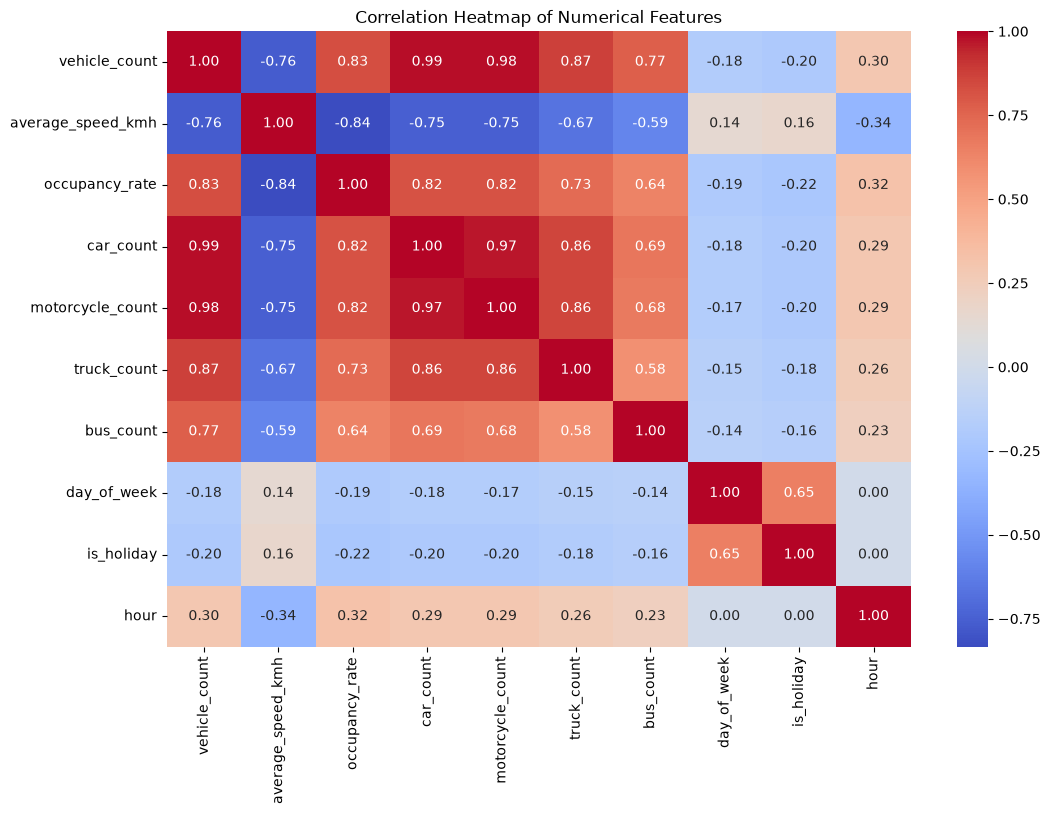

In [ ]:
import seaborn as sns

# Calculate correlation matrix
corr = df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Feature Engineering

In [66]:
def feature_engineering(
    df,
    target_column='vehicle_count',
    one_hot_sensor=True,
    add_lags=True,
    drop_lag_na=True,
    lag_steps=(1, 2),
):
    modern_df = df.copy()

    # Ensure timestamp is datetime and keep stable temporal order by sensor
    modern_df['timestamp'] = pd.to_datetime(modern_df['timestamp'])
    modern_df = modern_df.sort_values(['sensor_id', 'timestamp']).reset_index(drop=True)

    # Calendar features
    modern_df['month'] = modern_df['timestamp'].dt.month
    modern_df['day'] = modern_df['timestamp'].dt.day
    modern_df['hour'] = modern_df['timestamp'].dt.hour
    modern_df['minute'] = modern_df['timestamp'].dt.minute
    modern_df['day_of_week'] = modern_df['timestamp'].dt.dayofweek

    # Cyclical features requested: day, hour and day_of_week
    modern_df['day_sin'] = np.sin(2 * np.pi * modern_df['day'] / 31)
    modern_df['day_cos'] = np.cos(2 * np.pi * modern_df['day'] / 31)
    modern_df['hour_sin'] = np.sin(2 * np.pi * modern_df['hour'] / 24)
    modern_df['hour_cos'] = np.cos(2 * np.pi * modern_df['hour'] / 24)
    modern_df['day_of_week_sin'] = np.sin(2 * np.pi * modern_df['day_of_week'] / 7)
    modern_df['day_of_week_cos'] = np.cos(2 * np.pi * modern_df['day_of_week'] / 7)

    # Extra 30-minute cyclic signal to preserve intra-hour pattern
    modern_df['slot_30m'] = modern_df['hour'] * 2 + (modern_df['minute'] // 30)
    modern_df['slot_30m_sin'] = np.sin(2 * np.pi * modern_df['slot_30m'] / 48)
    modern_df['slot_30m_cos'] = np.cos(2 * np.pi * modern_df['slot_30m'] / 48)

    # Optional monthly cycle
    modern_df['month_sin'] = np.sin(2 * np.pi * modern_df['month'] / 12)
    modern_df['month_cos'] = np.cos(2 * np.pi * modern_df['month'] / 12)

    # Encode congestion level (fallback -1 for unseen labels)
    congestion_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
    modern_df['congestion_level'] = modern_df['congestion_level'].map(congestion_mapping).fillna(-1).astype('int16')

    # Lag features by sensor: lag 1 = 30 minutes, lag 2 = 60 minutes
    if add_lags:
        for step in lag_steps:
            modern_df[f'{target_column}_lag_{step}'] = modern_df.groupby('sensor_id')[target_column].shift(step)

    # sensor_id encoding for tabular models
    if one_hot_sensor:
        modern_df = pd.get_dummies(modern_df, columns=['sensor_id'], drop_first=True, dtype='int8')
    else:
        modern_df['sensor_id'] = modern_df['sensor_id'].astype('category')

    columns_to_drop = [
        'timestamp', 'location', 'direction',
        'car_count', 'motorcycle_count', 'truck_count', 'bus_count',
        'month', 'day', 'hour', 'minute', 'day_of_week'
    ]
    columns_to_drop = [c for c in columns_to_drop if c in modern_df.columns]
    modern_df.drop(columns=columns_to_drop, inplace=True)

    if add_lags and drop_lag_na:
        lag_cols = [c for c in modern_df.columns if c.startswith(f'{target_column}_lag_')]
        modern_df = modern_df.dropna(subset=lag_cols).reset_index(drop=True)

    return modern_df

def split_time_series_df(
    df,
    time_column='timestamp',
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
    use_validation=True,
):
    split_df = df.copy()
    split_df[time_column] = pd.to_datetime(split_df[time_column])
    split_df = split_df.sort_values(time_column).reset_index(drop=True)

    if use_validation:
        if not np.isclose(train_size + val_size + test_size, 1.0):
            raise ValueError('train_size + val_size + test_size must equal 1.0 when use_validation=True')
    else:
        if not np.isclose(train_size + test_size, 1.0):
            raise ValueError('train_size + test_size must equal 1.0 when use_validation=False')

    n = len(split_df)
    train_end = int(n * train_size)

    if use_validation:
        val_end = train_end + int(n * val_size)
        train_df = split_df.iloc[:train_end].copy()
        val_df = split_df.iloc[train_end:val_end].copy()
        test_df = split_df.iloc[val_end:].copy()
        return train_df, val_df, test_df

    train_df = split_df.iloc[:train_end].copy()
    test_df = split_df.iloc[train_end:].copy()
    return train_df, test_df

def classical_feature_engineering(df, time_column='timestamp', target_column='vehicle_count'):
    classical_df = df.copy()
    classical_df[time_column] = pd.to_datetime(classical_df[time_column])
    classical_df.set_index(time_column, inplace=True)

    classical_df = classical_df.rename(columns={target_column: 'y'})
    return classical_df

### Classical Approach

In [45]:
classical_df = classical_feature_engineering(df, time_column='timestamp', target_column='vehicle_count')

In [ ]:
# Daily Closing Price Plot
classical_df["y"].plot()
plt.show()

In [ ]:
# Plot the ACF of the
fig, ax = plt.subplots(figsize = (12, 6))
plot_acf(classical_df['y'], lags = 100, ax = ax)
plt.show()

In [ ]:
# PACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_pacf(classical_df['y'], lags = 100, ax = ax)
plt.show()

### Modern Approach

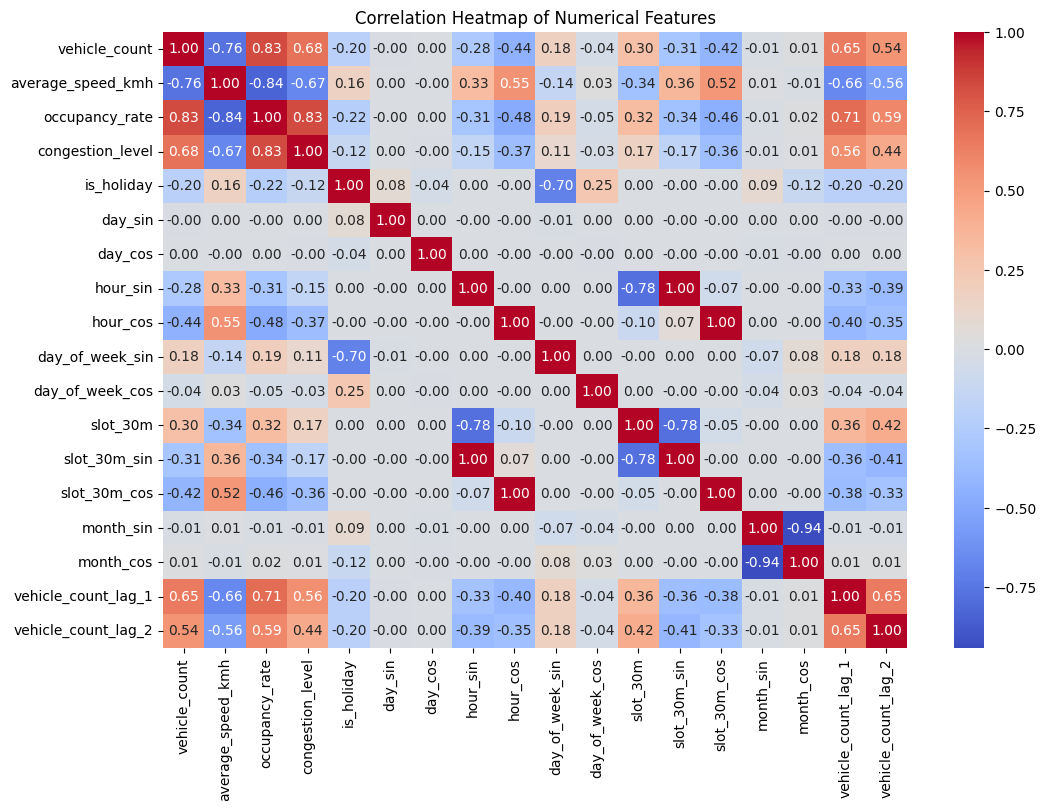

In [ ]:
import seaborn as sns

# Calculate correlation matrix from engineered training set
corr = modern_train_df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features (Train Split)')
plt.show()

# Models 

In [70]:
# Split original dataset first (temporal split, no leakage)
use_validation = False

if use_validation:
    train_df, val_df, test_df = split_time_series_df(
        df,
        time_column='timestamp',
        train_size=0.7,
        val_size=0.15,
        test_size=0.15,
        use_validation=True
    )
    print(f'Train rows: {len(train_df):,} | Val rows: {len(val_df):,} | Test rows: {len(test_df):,}')
else:
    train_df, test_df = split_time_series_df(
        df,
        time_column='timestamp',
        train_size=0.8,
        test_size=0.2,
        use_validation=False
    )
    print(f'Train rows: {len(train_df):,} | Test rows: {len(test_df):,}')

Train rows: 174,720 | Test rows: 43,680


In [71]:
# Apply the same feature engineering function to each split
modern_train_df = feature_engineering(
    train_df,
    target_column='vehicle_count',
    one_hot_sensor=True,
    add_lags=True,
    drop_lag_na=True,
    lag_steps=(1, 2)
 )

if use_validation:
    modern_val_df = feature_engineering(
        val_df,
        target_column='vehicle_count',
        one_hot_sensor=True,
        add_lags=True,
        drop_lag_na=True,
        lag_steps=(1, 2)
    )

modern_test_df = feature_engineering(
    test_df,
    target_column='vehicle_count',
    one_hot_sensor=True,
    add_lags=True,
    drop_lag_na=True,
    lag_steps=(1, 2)
 )

print('Engineered shapes:')
if use_validation:
    print('Train:', modern_train_df.shape, '| Val:', modern_val_df.shape, '| Test:', modern_test_df.shape)
else:
    print('Train:', modern_train_df.shape, '| Test:', modern_test_df.shape)

modern_train_df.head()

Engineered shapes:
Train: (174620, 67) | Test: (43580, 67)


,vehicle_count,average_speed_kmh,occupancy_rate,congestion_level,is_holiday,day_sin,day_cos,hour_sin,hour_cos,day_of_week_sin,...,sensor_id_SEN-041,sensor_id_SEN-042,sensor_id_SEN-043,sensor_id_SEN-044,sensor_id_SEN-045,sensor_id_SEN-046,sensor_id_SEN-047,sensor_id_SEN-048,sensor_id_SEN-049,sensor_id_SEN-050
0,21,80.0,0.149,1,1,0.201299,0.97953,0.258819,0.965926,0.0,...,0,0,0,0,0,0,0,0,0,0
1,25,80.0,0.171,1,1,0.201299,0.97953,0.258819,0.965926,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0,80.0,0.156,1,1,0.201299,0.97953,0.500000,0.866025,0.0,...,0,0,0,0,0,0,0,0,0,0
3,15,80.0,0.129,1,1,0.201299,0.97953,0.500000,0.866025,0.0,...,0,0,0,0,0,0,0,0,0,0
4,20,80.0,0.141,1,1,0.201299,0.97953,0.707107,0.707107,0.0,...,0,0,0,0,0,0,0,0,0,0


### LightGBM/Catboost 

In [72]:
from time import perf_counter
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score


def _safe_mape(y_true, y_pred, eps=1e-6):
    # Avoid exploding MAPE when true values are near zero
    y_true_safe = np.where(np.abs(y_true) < eps, eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true_safe))


def _smape(y_true, y_pred, eps=1e-6):
    denominator = np.abs(y_true) + np.abs(y_pred) + eps
    return np.mean(2.0 * np.abs(y_pred - y_true) / denominator)


def traing_and_test(
    train_df,
    test_df,
    target_column='vehicle_count',
    random_state=42,
    include_optional_models=True,
    verbose=True,
):
    """
    Benchmark main ML/DL-like regressors on train/test and return metrics.

    Notes:
    - Expects feature-engineered train/test dataframes.
    - Handles one-hot column mismatch by aligning test columns to train columns.
    - DL baseline here is MLPRegressor (fast NN baseline).
    """
    if target_column not in train_df.columns or target_column not in test_df.columns:
        raise ValueError(f"Target column '{target_column}' must exist in both train_df and test_df")

    # Prepare X/y
    X_train = train_df.drop(columns=[target_column]).copy()
    y_train = train_df[target_column].copy()
    X_test = test_df.drop(columns=[target_column]).copy()
    y_test = test_df[target_column].copy()

    # Ensure numeric inputs only
    X_train = X_train.select_dtypes(include=[np.number])
    X_test = X_test.select_dtypes(include=[np.number])

    # Align columns in case one-hot differs between train and test
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    models = {
        'LinearRegression': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LinearRegression())
        ]),
        'GradientBoosting': GradientBoostingRegressor(random_state=random_state),
        'RandomForest': RandomForestRegressor(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1
        ),
        'ExtraTrees': ExtraTreesRegressor(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1
        ),
        'MLPRegressor': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPRegressor(
                hidden_layer_sizes=(128, 64),
                activation='relu',
                solver='adam',
                learning_rate_init=1e-3,
                max_iter=200,
                early_stopping=True,
                random_state=random_state
            ))
        ])
    }

    if include_optional_models:
        try:
            from catboost import CatBoostRegressor
            models['CatBoost'] = CatBoostRegressor(
                iterations=600,
                learning_rate=0.05,
                depth=8,
                loss_function='RMSE',
                random_seed=random_state,
                verbose=False
            )
        except Exception:
            pass

        try:
            from lightgbm import LGBMRegressor
            models['LightGBM'] = LGBMRegressor(
                n_estimators=600,
                learning_rate=0.05,
                num_leaves=63,
                random_state=random_state
            )
        except Exception:
            pass

    rows = []
    predictions = {}

    for model_name, model in models.items():
        start = perf_counter()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        elapsed = perf_counter() - start

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        mape = _safe_mape(y_test.to_numpy(), y_pred)
        smape = _smape(y_test.to_numpy(), y_pred)
        r2 = r2_score(y_test, y_pred)

        rows.append({
            'model': model_name,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'smape': smape,
            'r2': r2,
            'fit_predict_seconds': elapsed
        })
        predictions[model_name] = y_pred

        if verbose:
            print(f"{model_name:<18} RMSE={rmse:.3f} | MAE={mae:.3f} | MAPE={mape:.4f} | sMAPE={smape:.4f} | R2={r2:.4f}")

    results_df = pd.DataFrame(rows).sort_values('rmse').reset_index(drop=True)
    return results_df, predictions


benchmark_results, benchmark_predictions = traing_and_test(
    modern_train_df,
    modern_test_df,
    target_column='vehicle_count',
    random_state=42,
    include_optional_models=True,
    verbose=True
)

display(benchmark_results)

LinearRegression   RMSE=15.188 | MAE=11.687 | MAPE=118811.8292 | sMAPE=0.3850 | R2=0.7081
GradientBoosting   RMSE=13.865 | MAE=10.610 | MAPE=113929.7546 | sMAPE=0.3440 | R2=0.7567
RandomForest       RMSE=13.982 | MAE=10.662 | MAPE=111481.3807 | sMAPE=0.3455 | R2=0.7526
ExtraTrees         RMSE=14.183 | MAE=10.784 | MAPE=110623.9581 | sMAPE=0.3497 | R2=0.7454
MLPRegressor       RMSE=14.017 | MAE=10.706 | MAPE=122127.8752 | sMAPE=0.3454 | R2=0.7514


,model,rmse,mae,mape,smape,r2,fit_predict_seconds
0,GradientBoosting,13.865136,10.610195,113929.754613,0.343977,0.756720,59.493759
1,RandomForest,13.982163,10.661817,111481.380669,0.345509,0.752596,260.675837
2,MLPRegressor,14.016590,10.705635,122127.875210,0.345420,0.751376,128.699763
3,ExtraTrees,14.182887,10.784155,110623.958071,0.349660,0.745442,229.285825
4,LinearRegression,15.187704,11.686830,118811.829243,0.385031,0.708094,0.924432


### TFT

### Modern Techniques: AutoGluon